**SoilHive - Surface Soil Dataset Construction Pipeline**

**Objective**
Build a clean, ML-ready soil dataset from heterogeneous geospatial observations using:
- Depth-aware aggregation
- Temporal cleaning
- Spatial aggregation
- Country-level structuring


**Overview**
1. Load all CSVs 
2. Clean + standardize 
3. Filter valid surface layers (0–30 cm overlap) 
4. Depth-weighted aggregation (per observation) 
5. Temporal filtering (optional but recommended) 
6. Spatial aggregation (handle duplicates) 
7. Pivot to wide format 
8. Add uncertainty features 
9. Add country 10 Split by country 

**0. Setup**

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from glob import glob

BASE = Path('/home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/extracted')

SURFACE_MIN = 0
SURFACE_MAX = 30

PROPERTIES = [
    'Al', 'BD', 'Ca', 'CaCO3', 'CEC', 'CF', 'clay', 'Cu', 'EC', 'Fe',
    'K', 'Mg', 'Mn', 'N', 'Na', 'nematode', 'occ', 'P', 'pH', 'sand',
    'silt', 'TC', 'WR_gravimetric', 'WR_volumetric'
]

**1. Load all datasets**

In [2]:
def load_all_csvs(base_path):
    files = glob(str(base_path / "**/output_data_points.csv"), recursive=True)
    
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["source_file"] = Path(f).parent.name
        dfs.append(df)
    
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

df = load_all_csvs(BASE)
df

,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source,source_file
0,1,-19.4157,22.0154,CEC,soil_ECEC,0.0,20.0,0.000100,cmol/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted
1,2,-19.4157,22.0154,P,soil_P_total,0.0,20.0,21.906250,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted
2,3,-19.4157,22.0154,Na,soil_ex_Na,0.0,20.0,0.000100,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted
3,4,-19.4157,22.0154,pH,soil_pH,0.0,20.0,5.230469,NaN,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted
4,5,-19.4157,22.0154,Mg,soil_ex_Mg,0.0,20.0,0.203125,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2037628,205,-19.3410,22.0368,Mn,manganese_extractable,0.0,20.0,47.609000,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2023-01-01,iSDA Field Data,2d7uogpw
2037629,206,-19.3410,22.0368,N,nitrogen_total,0.0,20.0,0.590000,g/kg,NaN,CC BY 4.0,83974cfffffffff,2023-01-01,iSDA Field Data,2d7uogpw
2037630,207,-19.3410,22.0368,pH,ph_h20,0.0,20.0,6.486000,NaN,NaN,CC BY 4.0,83974cfffffffff,2023-01-01,iSDA Field Data,2d7uogpw
2037631,208,-19.3410,22.0368,K,potassium_extractable,0.0,20.0,104.765000,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2023-01-01,iSDA Field Data,2d7uogpw


In [3]:
df["data_source"].value_counts()

data_source
WoSIS                      1872802
iSDA Field Data             122572
Global Soil Nematode DB      25158
CAROB                        17101
Name: count, dtype: int64

**2. Basic cleaning**

In [4]:
def basic_clean(df):
    df = df.copy()
    df = df.dropna(subset=["lat", "lon", "value", "property"])
    
    df = df[df["property"].isin(PROPERTIES)]
    
    # Depth consistency
    df = df[df["upper_depth_cm"] < df["lower_depth_cm"]]
    
    # Convert date
    df["sampling_date"] = pd.to_datetime(df["sampling_date"], errors="coerce")

    # Remove duplicates
    print(f"df before {df.shape}")
    df = df.drop_duplicates()
    print(f"df after {df.shape}")


    
    return df

df = basic_clean(df)

df before (2024192, 15)
df after (2024191, 15)


**3. Surface overlap filtering (KEY STEP)** (Keep layers that intersect [0–30 cm])

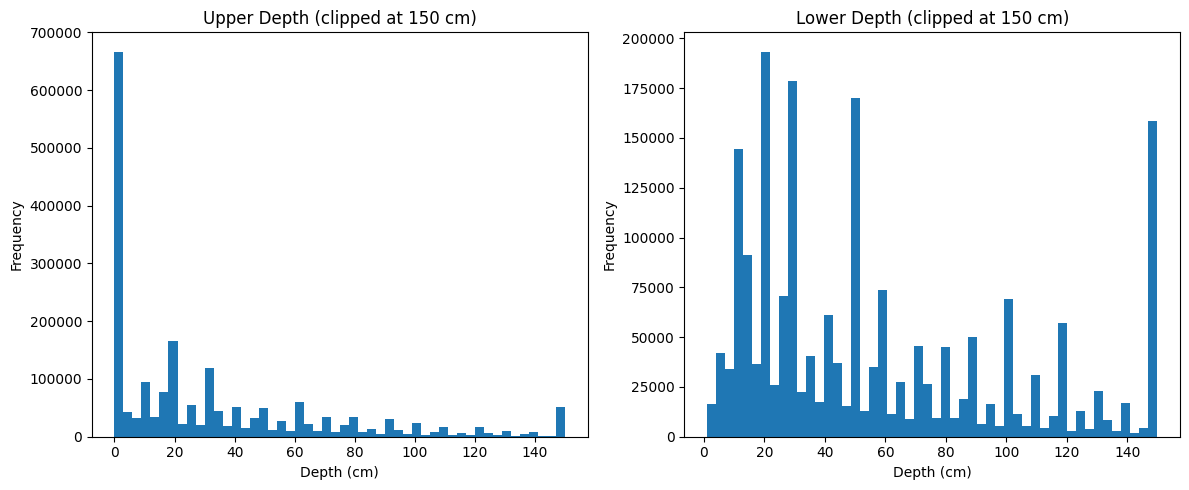

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Clip extreme depths for visualization
upper = df["upper_depth_cm"].clip(0, 150)
lower = df["lower_depth_cm"].clip(0, 150)

# Upper depth
plt.subplot(1, 2, 1)
plt.hist(upper.dropna(), bins=50)
plt.title("Upper Depth (clipped at 150 cm)")
plt.xlabel("Depth (cm)")
plt.ylabel("Frequency")

# Lower depth
plt.subplot(1, 2, 2)
plt.hist(lower.dropna(), bins=50)
plt.title("Lower Depth (clipped at 150 cm)")
plt.xlabel("Depth (cm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

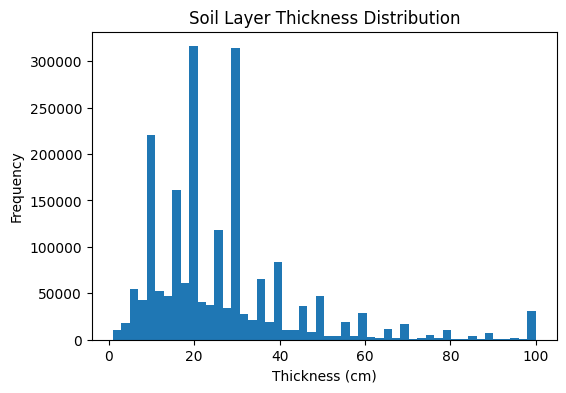

In [6]:
thickness = df["lower_depth_cm"] - df["upper_depth_cm"]

plt.figure(figsize=(6, 4))
plt.hist(thickness.dropna().clip(0, 100), bins=50)
plt.title("Soil Layer Thickness Distribution")
plt.xlabel("Thickness (cm)")
plt.ylabel("Frequency")
plt.show()

The dataset is dominated by surface-starting layers (upper depth approx 0 cm) with standard horizon endpoints (20 - 30 cm), but also includes deep and heterogeneous profiles up to 150 cm, indicating mixed sampling strategies.
This variability in depth and layer thickness confirms the need for depth-weighted aggregation restricted to 0 - 30 cm to obtain a consistent and agronomically meaningful surface soil representation for modeling.

In [7]:
def compute_overlap(row):
    upper = row["upper_depth_cm"]
    lower = row["lower_depth_cm"]
    
    overlap = max(0, min(lower, SURFACE_MAX) - max(upper, SURFACE_MIN))
    thickness = lower - upper
    if thickness <= 0:
        return 0
    
    return overlap / thickness 

df["overlap_weight"] = df.apply(compute_overlap, axis=1)

df_surface = df[df["overlap_weight"] > 0].copy()

**4. Depth-weighted aggregation (per point)**

In [8]:
def depth_weighted_agg(df):
    return (
        df
        .groupby(["lat", "lon", "property", "sampling_date"])
        .apply(lambda g: np.average(g["value"], weights=g["overlap_weight"]))
        .reset_index(name="value_weighted")
    )
df_depth = depth_weighted_agg(df_surface)
df_depth

/tmp/ipykernel_368807/1939818426.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["value"], weights=g["overlap_weight"]))


,lat,lon,property,sampling_date,value_weighted
0,-43.515201,146.884688,CEC,1970-01-01 00:00:00.000001958,41.633333
1,-43.515201,146.884688,CF,1970-01-01 00:00:00.000001958,0.000000
2,-43.515201,146.884688,EC,1970-01-01 00:00:00.000001958,0.186486
3,-43.515201,146.884688,N,1970-01-01 00:00:00.000001958,4.754054
4,-43.515201,146.884688,clay,1970-01-01 00:00:00.000001958,10.142857
...,...,...,...,...,...
200872,59.470000,26.770000,pH,1970-01-01 00:00:00.000001995,6.975000
200873,59.470000,26.770000,sand,1970-01-01 00:00:00.000001995,70.500000
200874,59.470000,26.770000,silt,1970-01-01 00:00:00.000001995,22.500000
200875,59.500000,26.000000,CaCO3,1970-01-01 00:00:00.000001989,0.000000


The depth-weighted aggregation successfully transforms heterogeneous soil layers into a consistent surface representation by accounting for each layer’s contribution within the 0 - 30 cm range. This results in a more reliable and agronomically meaningful dataset, where values reflect true surface conditions rather than biased or arbitrary layer selections.

**5. Temporal filtering (IMPORTANT)**

In [9]:
df["sampling_date"].value_counts()

sampling_date
1970-01-01 00:00:00.000001986    107340
1970-01-01 00:00:00.000001987     61704
1970-01-01 00:00:00.000001995     60026
1970-01-01 00:00:00.000001985     57997
1970-01-01 00:00:00.000001997     56312
                                  ...  
1970-01-01 00:00:00.000001931       433
1970-01-01 00:00:00.000001920       244
1970-01-01 00:00:00.000001938       193
1970-01-01 00:00:00.000001945       138
1970-01-01 00:00:00.000001940        32
Name: count, Length: 75, dtype: int64

In [11]:
def temporal_filter(df, min_year=2000):
    df = df.dropna(subset=["sampling_date"])
    df = df.copy()
    df["sampling_date"] = pd.to_datetime(
        df["sampling_date"].astype(int).astype(str),
        format="%Y",
        errors="coerce"
    )
    df["year"] = df["sampling_date"].dt.year
    print(f"Min : { df['year'].min()}, Max : {df['year'].max()}")
    return df[df["year"] >= min_year]

df_depth = temporal_filter(df_depth)
df_depth.head()

Min : 1920, Max : 2015


,lat,lon,property,sampling_date,value_weighted,year
8,-43.401663,147.319739,CEC,2007-01-01,9.628571,2007
9,-43.401663,147.319739,EC,2007-01-01,0.100000,2007
10,-43.401663,147.319739,N,2007-01-01,2.142857,2007
11,-43.401663,147.319739,P,2007-01-01,13.100000,2007
12,-43.401663,147.319739,occ,2007-01-01,49.800000,2007


**6. Spatial aggregation (handle duplicates)**

In [12]:
def spatial_aggregation(df):
    agg = (
        df
        .groupby(["lat", "lon", "property"])
        .agg(
            mean_value=("value_weighted", "mean"),
            std_value=("value_weighted", "std"),
            n_obs=("value_weighted", "count"),
            min_year=("year", "min"),
            max_year=("year", "max")
        )
        .reset_index()
    )
    
    return agg

df_agg = spatial_aggregation(df_depth)
df_agg

,lat,lon,property,mean_value,std_value,n_obs,min_year,max_year
0,-43.401663,147.319739,CEC,9.628571,NaN,1,2007,2007
1,-43.401663,147.319739,EC,0.100000,NaN,1,2007,2007
2,-43.401663,147.319739,N,2.142857,NaN,1,2007,2007
3,-43.401663,147.319739,P,13.100000,NaN,1,2007,2007
4,-43.401663,147.319739,occ,49.800000,NaN,1,2007,2007
...,...,...,...,...,...,...,...,...
52709,53.789823,12.073884,TC,9.400000,NaN,1,2006,2006
52710,53.789823,12.073884,clay,11.500000,NaN,1,2006,2006
52711,53.789823,12.073884,occ,9.400000,NaN,1,2006,2006
52712,53.789823,12.073884,sand,63.400000,NaN,1,2006,2006


**7. Pivot to wide format**

In [13]:
def pivot_wide(df):
    df_wide = df.pivot(index=["lat", "lon"], columns="property", values="mean_value")
    df_wide.columns.name = None
    df_wide = df_wide.reset_index()
    
    return df_wide

df_wide = pivot_wide(df_agg)
df_wide

,lat,lon,BD,CEC,CF,CaCO3,EC,N,P,TC,WR_gravimetric,WR_volumetric,clay,occ,pH,sand,silt
0,-43.401663,147.319739,NaN,9.628571,NaN,NaN,0.100000,2.142857,13.100000,NaN,NaN,NaN,NaN,49.800000,4.442857,NaN,NaN
1,-43.181667,146.849301,NaN,10.583871,NaN,NaN,0.148387,2.883871,4.875806,NaN,NaN,NaN,NaN,50.791935,4.228226,NaN,NaN
2,-43.090378,146.658000,NaN,14.960000,NaN,NaN,0.160000,3.740000,4.140000,NaN,NaN,NaN,NaN,48.320000,4.910000,NaN,NaN
3,-43.046337,146.707405,NaN,14.754545,NaN,NaN,0.172727,3.072727,15.472727,NaN,NaN,NaN,NaN,49.418182,5.145455,NaN,NaN
4,-43.016290,146.950863,NaN,53.139130,NaN,NaN,0.113043,2.443478,5.034783,NaN,NaN,NaN,NaN,30.913043,6.502174,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10657,53.789348,12.072854,1.57,NaN,NaN,0.0,NaN,0.640000,NaN,6.3,NaN,NaN,6.2,6.300000,NaN,72.9,20.9
10658,53.789363,12.073460,1.70,NaN,NaN,0.0,NaN,0.790000,NaN,7.4,NaN,NaN,8.0,7.400000,NaN,66.8,25.2
10659,53.789527,12.072842,1.60,NaN,NaN,0.1,NaN,0.670000,NaN,6.5,NaN,NaN,6.3,6.400000,NaN,72.8,20.9
10660,53.789613,12.072684,1.79,NaN,NaN,0.0,NaN,0.700000,NaN,6.9,NaN,NaN,7.1,6.900000,NaN,70.2,22.7


**8. Add uncertainty features**

In [14]:
def add_uncertainty(df_agg, df_wide):
    std_pivot = df_agg.pivot(index=["lat", "lon"], columns="property", values="std_value")
    count_pivot = df_agg.pivot(index=["lat", "lon"], columns="property", values="n_obs")
    
    std_pivot = std_pivot.add_suffix("_std")
    count_pivot = count_pivot.add_suffix("_n")
    
    df_uncertainty = df_wide.merge(std_pivot, on=["lat", "lon"], how="left")
    df_uncertainty = df_uncertainty.merge(count_pivot, on=["lat", "lon"], how="left")
    
    return df_uncertainty

df_uncertainty = add_uncertainty(df_agg, df_wide)
df_uncertainty

,lat,lon,BD,CEC,CF,CaCO3,EC,N,P,TC,...,N_n,P_n,TC_n,WR_gravimetric_n,WR_volumetric_n,clay_n,occ_n,pH_n,sand_n,silt_n
0,-43.401663,147.319739,NaN,9.628571,NaN,NaN,0.100000,2.142857,13.100000,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN
1,-43.181667,146.849301,NaN,10.583871,NaN,NaN,0.148387,2.883871,4.875806,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN
2,-43.090378,146.658000,NaN,14.960000,NaN,NaN,0.160000,3.740000,4.140000,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN
3,-43.046337,146.707405,NaN,14.754545,NaN,NaN,0.172727,3.072727,15.472727,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN
4,-43.016290,146.950863,NaN,53.139130,NaN,NaN,0.113043,2.443478,5.034783,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10657,53.789348,12.072854,1.57,NaN,NaN,0.0,NaN,0.640000,NaN,6.3,...,1.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN,1.0,1.0
10658,53.789363,12.073460,1.70,NaN,NaN,0.0,NaN,0.790000,NaN,7.4,...,1.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN,1.0,1.0
10659,53.789527,12.072842,1.60,NaN,NaN,0.1,NaN,0.670000,NaN,6.5,...,1.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN,1.0,1.0
10660,53.789613,12.072684,1.79,NaN,NaN,0.0,NaN,0.700000,NaN,6.9,...,1.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN,1.0,1.0


**9. Add country**

In [16]:
import geopandas as gpd
import geodatasets
from shapely.geometry import Point

def add_country(df):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )

    world = gpd.read_file(
        "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    )
    gdf = gpd.sjoin(
        gdf,
        world[["geometry", "ADMIN"]],
        how="left",
        predicate="within"
    )

    gdf = gdf.rename(columns={"ADMIN": "country"})

    return gdf.drop(columns=["geometry", "index_right"])

df_country = add_country(df_uncertainty)
df_country.head()

,lat,lon,BD,CEC,CF,CaCO3,EC,N,P,TC,...,P_n,TC_n,WR_gravimetric_n,WR_volumetric_n,clay_n,occ_n,pH_n,sand_n,silt_n,country
0,-43.401663,147.319739,NaN,9.628571,NaN,NaN,0.100000,2.142857,13.100000,NaN,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
1,-43.181667,146.849301,NaN,10.583871,NaN,NaN,0.148387,2.883871,4.875806,NaN,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,Australia
2,-43.090378,146.658000,NaN,14.960000,NaN,NaN,0.160000,3.740000,4.140000,NaN,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,Australia
3,-43.046337,146.707405,NaN,14.754545,NaN,NaN,0.172727,3.072727,15.472727,NaN,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,Australia
4,-43.016290,146.950863,NaN,53.139130,NaN,NaN,0.113043,2.443478,5.034783,NaN,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,Australia


In [17]:
print(f"Pts without country (Before): {df_country['country'].isna().sum()}")
df_country = df_country.dropna(subset=["country"])
print(f"Pts without country (After): {df_country['country'].isna().sum()}")

Pts without country (Before): 230
Pts without country (After): 0


In [18]:
nan_ratio = df_country.isna().mean().sort_values(ascending=False)
nan_ratio

TC_std                1.000000
WR_gravimetric_std    1.000000
CF_std                1.000000
WR_volumetric_std     1.000000
BD_std                1.000000
N_std                 0.999808
sand_std              0.998754
P_std                 0.998658
CEC_std               0.998562
CaCO3_std             0.998466
occ_std               0.997891
clay_std              0.997795
silt_std              0.997795
EC_std                0.997316
pH_std                0.993673
TC                    0.993002
TC_n                  0.993002
WR_volumetric_n       0.990318
WR_volumetric         0.990318
BD_n                  0.983896
BD                    0.983896
N                     0.858416
N_n                   0.858416
WR_gravimetric_n      0.853719
WR_gravimetric        0.853719
CF_n                  0.801764
CF                    0.801764
CaCO3                 0.763420
CaCO3_n               0.763420
sand                  0.747508
sand_n                0.747508
CEC                   0.673505
CEC_n   

In [19]:
print("Befor columns:", df_country.shape[1])
df_country = df_country.dropna(axis=1, how="all")
print("Remaining columns:", df_country.shape[1])

Befor columns: 48
Remaining columns: 43


**10. Split dataset by country**

In [20]:
df_country['country'].value_counts()

country
Australia       8012
France          2081
Netherlands      167
Germany           81
Switzerland       30
Cameroon          16
Burkina Faso      15
Albania            9
Georgia            6
Belgium            4
Benin              4
Italy              3
Luxembourg         2
Tunisia            1
Spain              1
Name: count, dtype: int64

Select top 4 countries

In [21]:
top_countries = ["Australia", "France", "Netherlands", "Germany"]
country_dfs = {
    country: group.copy()
    for country, group in df_country.groupby("country")
    if country in top_countries
}
for k, v in country_dfs.items():
    print(k, v.shape)


Australia (8012, 43)
France (2081, 43)
Germany (81, 43)
Netherlands (167, 43)


In [22]:
for country, df in country_dfs.items():
    print(f"\n=== {country} ===")
    print(df.isna().mean().sort_values(ascending=False))


=== Australia ===
TC                  1.000000
TC_n                1.000000
sand_std            1.000000
P_std               0.999875
CEC_std             0.999750
N_std               0.999750
CaCO3_std           0.999626
occ_std             0.998877
clay_std            0.998752
silt_std            0.998752
EC_std              0.996505
pH_std              0.993385
BD                  0.989890
BD_n                0.989890
WR_volumetric       0.987394
WR_volumetric_n     0.987394
CaCO3               0.965177
CaCO3_n             0.965177
sand                0.949825
sand_n              0.949825
CEC_n               0.838492
CEC                 0.838492
N_n                 0.829880
N                   0.829880
WR_gravimetric      0.810659
WR_gravimetric_n    0.810659
P                   0.774963
P_n                 0.774963
CF_n                0.744383
CF                  0.744383
silt_n              0.511233
silt                0.511233
clay                0.509860
clay_n              0.50

In [23]:
def get_threshold(n):
    if n > 5000:
        return 0.7
    elif n > 1000:
        return 0.6  
    elif n > 100:
        return 0.6  
    else:
        return 0.7   

cleaned_country_dfs = {}

for country, df_c in country_dfs.items():
    
    threshold = get_threshold(len(df_c))
    
    nan_ratio = df_c.isna().mean()
    cols_to_keep = nan_ratio[nan_ratio <= threshold].index
    df_clean = df_c[cols_to_keep].copy()
    df_clean = df_clean.fillna(df_clean.median(numeric_only=True))
    cleaned_country_dfs[country] = df_clean

In [24]:
for country, df in cleaned_country_dfs.items():
    print(f"\n=== {country} ===")
    print(df.isna().mean().sort_values(ascending=False))


=== Australia ===
lat        0.0
lon        0.0
EC         0.0
clay       0.0
occ        0.0
pH         0.0
silt       0.0
EC_n       0.0
clay_n     0.0
occ_n      0.0
pH_n       0.0
silt_n     0.0
country    0.0
dtype: float64

=== France ===
lat        0.0
lon        0.0
CEC        0.0
CaCO3      0.0
P          0.0
clay       0.0
occ        0.0
pH         0.0
sand       0.0
silt       0.0
CEC_n      0.0
CaCO3_n    0.0
P_n        0.0
clay_n     0.0
occ_n      0.0
pH_n       0.0
sand_n     0.0
silt_n     0.0
country    0.0
dtype: float64

=== Germany ===
lat        0.0
lon        0.0
BD         0.0
CaCO3      0.0
N          0.0
TC         0.0
clay       0.0
occ        0.0
sand       0.0
silt       0.0
BD_n       0.0
CaCO3_n    0.0
N_n        0.0
TC_n       0.0
clay_n     0.0
occ_n      0.0
sand_n     0.0
silt_n     0.0
country    0.0
dtype: float64

=== Netherlands ===
lat        0.0
lon        0.0
silt       0.0
silt_n     0.0
country    0.0
dtype: float64


In [25]:
for country, df in cleaned_country_dfs.items():
    print(f"\n=== {country} ===")
    display(df.head(10))
    print(f"Shape : {df.shape}")


=== Australia ===


,lat,lon,EC,clay,occ,pH,silt,EC_n,clay_n,occ_n,pH_n,silt_n,country
1,-43.181667,146.849301,0.148387,28.6,50.791935,4.228226,15.657912,1.0,1.0,1.0,1.0,1.0,Australia
2,-43.090378,146.658000,0.160000,28.6,48.320000,4.910000,15.657912,1.0,1.0,1.0,1.0,1.0,Australia
3,-43.046337,146.707405,0.172727,28.6,49.418182,5.145455,15.657912,1.0,1.0,1.0,1.0,1.0,Australia
4,-43.016290,146.950863,0.113043,28.6,30.913043,6.502174,15.657912,1.0,1.0,1.0,1.0,1.0,Australia
5,-42.909558,147.903023,0.000000,28.6,13.900000,5.407143,15.657912,1.0,1.0,1.0,1.0,1.0,Australia
6,-42.890840,147.935204,0.000000,28.6,13.900000,6.516667,15.657912,1.0,1.0,1.0,1.0,1.0,Australia
7,-42.886626,147.954734,0.000000,28.6,13.900000,5.930952,15.657912,1.0,1.0,1.0,1.0,1.0,Australia
8,-42.886242,147.946768,0.000000,28.6,13.900000,5.969231,15.657912,1.0,1.0,1.0,1.0,1.0,Australia
9,-42.821976,147.461236,0.100000,28.6,17.594595,6.064865,15.657912,1.0,1.0,1.0,1.0,1.0,Australia
10,-42.812229,147.723027,0.100000,28.6,13.900000,5.633333,15.657912,1.0,1.0,1.0,1.0,1.0,Australia


Shape : (8012, 13)

=== France ===


,lat,lon,CEC,CaCO3,P,clay,occ,pH,sand,silt,CEC_n,CaCO3_n,P_n,clay_n,occ_n,pH_n,sand_n,silt_n,country
8239,4.772211,-52.131111,11.4,0.5,781.0,21.2,26.391667,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France
8240,4.772274,-52.131256,11.4,0.5,781.0,21.2,20.900000,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France
8241,4.788874,-52.161945,11.4,0.5,781.0,21.2,9.141667,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France
8242,5.347671,-52.843723,11.4,0.5,781.0,21.2,10.412500,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France
8243,5.348996,-52.844898,11.4,0.5,781.0,21.2,19.391667,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France
8244,5.361213,-52.886009,11.4,0.5,781.0,21.2,104.000000,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France
8245,5.361244,-52.887886,11.4,0.5,781.0,21.2,79.061765,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France
8246,5.361265,-52.886715,11.4,0.5,781.0,21.2,145.583333,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France
8247,5.379758,-52.920780,11.4,0.5,781.0,21.2,68.750000,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France
8248,5.421722,-53.003498,11.4,0.5,781.0,21.2,65.883333,6.2,30.1,40.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,France


Shape : (2081, 19)

=== Germany ===


,lat,lon,BD,CaCO3,N,TC,clay,occ,sand,silt,BD_n,CaCO3_n,N_n,TC_n,clay_n,occ_n,sand_n,silt_n,country
9964,48.439569,7.731805,1.595000,183.000000,1.000000,11.050000,28.200000,18.800000,26.100000,45.700000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany
10114,48.859865,7.994063,1.595000,0.500000,1.000000,11.050000,7.600000,122.822222,73.500000,18.900000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany
10120,48.911444,8.413693,1.603571,0.307143,0.861071,9.046429,18.432143,8.739286,13.903571,67.664286,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany
10121,48.911786,8.413374,1.400000,26.800000,0.910000,34.400000,0.200000,7.600000,28.700000,71.100000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany
10122,48.911922,8.414176,1.500000,0.100000,1.140000,11.700000,15.600000,11.600000,20.100000,64.300000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany
10123,48.912066,8.415113,1.500000,2.600000,0.990000,12.400000,12.500000,9.900000,18.600000,68.900000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany
10124,48.912085,8.413881,1.400000,0.100000,1.240000,12.300000,13.300000,12.200000,22.800000,63.900000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany
10125,48.912481,8.414512,1.541176,0.100000,0.944706,9.447059,11.611765,9.347059,18.488235,69.900000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany
10128,48.923751,12.447163,1.700000,0.100000,1.210000,11.100000,11.100000,11.000000,63.800000,25.100000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany
10129,48.923781,12.448526,1.600000,0.100000,1.050000,9.600000,8.600000,9.500000,71.100000,20.300000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Germany


Shape : (81, 19)

=== Netherlands ===


,lat,lon,silt,silt_n,country
10443,51.306695,5.486897,15.0,1.0,Netherlands
10444,51.309941,5.529141,15.0,1.0,Netherlands
10446,51.332229,5.821338,15.0,1.0,Netherlands
10449,51.370029,5.719664,13.4,1.0,Netherlands
10452,51.493416,4.718624,8.3,1.0,Netherlands
10453,51.506536,5.180422,15.0,1.0,Netherlands
10454,51.511249,4.625863,15.0,1.0,Netherlands
10456,51.527300,5.263993,15.0,1.0,Netherlands
10457,51.585880,4.509796,21.0,1.0,Netherlands
10470,51.651247,4.433792,15.0,1.0,Netherlands


Shape : (167, 5)


In [26]:
from pathlib import Path

OUTPUT_DIR = Path("/home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/clean_by_country")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for country, df in country_dfs.items():
    country_clean = country.replace(" ", "_")
    file_path = OUTPUT_DIR / f"{country_clean}.csv"
    df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

Saved: /home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/clean_by_country/Australia.csv
Saved: /home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/clean_by_country/France.csv
Saved: /home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/clean_by_country/Germany.csv
Saved: /home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/clean_by_country/Netherlands.csv
